# Rubisco phase planes on iCH360

This Jupyter notebook computes the Phenotypic phase planes (rubisco carboxylation flux vs. biomass production) for two
growth-coupled mutants, computed on the **iCH360** *E. coli* model. First, we provide a synopsis of the calculation:

**1. Built the iCH360+rpp model** (`iCH360_with_rpp.xml`)

We augmented the iCH360 model with the relevant metabolites and reactions which are not included in it.

Added the following metabolites:
- D-ribulose 1,5-bisphosphate `rubp__D_c` (C5H12O11P2)
- 2-dehydro-3-deoxy-D-gluconate 6-phosphate `2ddg6p_c` (C6H8O9P)
- 2-Phosphoglycolate `2pglyc_c` (C2H2O6P)
- Glycolate `glyclt_c` (C2H3O3)

Added the following reactions:
- phosphoribulokinase (`PRK`: `atp_c + ru5p__D_c → adp_c + rubp__D_c`)
- rubisco carboxylation (`RBC`: `co2_c + h2o_c + rubp__D_c → 2 3pg_c + 3 h_c`)
- rubisco oxygenation (`RBC_OX`: `rubp__D_c + o2_c → 3pg_c + 2pglyc_c + h_c`)
- Entner-Doudoroff reactions (`EDD`: `6pgc_c → 2ddg6p_c + h2o_c` and `R_EDA`: `2ddg6p_c → g3p_c + pyr_c`)
- phosphoglycolate phosphatase (`PGLYCP`)
- glycolate oxidase (`GLYCTO1`)
- glycine-oxaloacetate transaminase (`GLYOAT`)


**2. Phenotypic phase planes comparing the two mutants**

- 3 possible carbon sources were introduced by activating the exchange reactions:
    - `EX_glyc_e` (glycerol)
    - `EX_xyl__D_e` (xylose)
    - `EX_glc__D_e` (glucose)
- Mutants were constructed by knocking out reactions from the model:
    - **ΔrpiAB Δedd Δeda** : which in the model are represented by `RPI`, `EDD`, `EDA`
    - **ΔaceA ΔglyA** : (i.e. the GLY-AUX2 strain) which in the model are represented by `ICL`, `GHMT2r`
- Target reactions (plotted against biomass production rate):
    - `RBC` : rubisco carboxylation (while oxygenation is completely repressed)
    - `RBC_OX` : rubisco oxygenation (while carboxylation is completely repressed)


**3. O₂/CO₂ ratio sweep (carboxylation vs. oxygenation)**

We **impose** the oxygenation:carboxylation flux ratio and sweep it on a log-scale,

$$\varphi = \log_{10}\!\frac{v(\text{RBC\_OX})}{v(\text{RBC})}, \qquad \varphi \in [-4, 4]$$

while constraining the sum of both rubisco fluxes to 1 μmol/min/gCDW. We then maximize growth of the GLY-AUX2 mutant growing on glycerol (at each φ).  Since carboxylation is counter-productive in this mutant, the function is monotonically increasing with φ (i.e. more oxygenation is better).

**4. Phenotypic phase planes of GLY-AUX2 for different values of φ**

- We use the same model, carbon source, and knockouts as in the previous section.
- The envelope is computed by sweeping the flux in `RBC`, while the flux ratio between `RBC_OX` and `RBC` is pinned to `10**φ`. Therefore, the total Rubisco flux is `RBC*(1 + 10**φ)`.
- After computing each phase plane, its y-axis is rescaled to show the total Rubisco flux (instead of just `RBC` flux).


In [1]:
import os
import numpy as np

import cobra
from cobra.io import read_sbml_model
from cobra.core import model
from cobra.flux_analysis import phenotype_phase_plane, pfba
from typing import List, Tuple, Iterable, Any
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Use the open-source GLPK solver by default (override with OPTSLOPE_SOLVER,
# e.g. "gurobi" if you have a license). This mirrors optslope's default and
# avoids failing when no Gurobi license is available.
cobra.Configuration().solver = os.environ.get("OPTSLOPE_SOLVER", "glpk")

wt_model = read_sbml_model("iCH360_with_rpp.xml")

In [2]:
# modified version of plotting.plot_production_envelope
# let's us put multiple planes on the same plot. 
def production_envelope(
        wt_model: model,
        knockouts: Iterable[str],
        carbon_sources: Iterable[str],
        target_reaction: str,
        points: int = 20
) -> pd.DataFrame:
    """Calculates the data of the production envelope for a KO.

    :param wt_model: the Wild-Type model without any knockouts
    :param knockouts: the list of KOs
    :param carbon_sources: the list of carbon sources
    :param target_reaction: the reaction to place on the x-axis of the PPP
    :return: A DataFrame with the biomass yield ranges for each x-value
    """
    ko_model = wt_model.copy()
    for ko in knockouts:
        for k in ko.split('|'):
            ko_model.reactions.get_by_id(k).knock_out()
    # iCH360 ships with glucose uptake open by default; close it so the chosen
    # carbon source is the only one available (the old core model had no default
    # carbon source, so it didn't need this).
    ko_model.reactions.EX_glc__D_e.lower_bound = 0.0
    for cs in carbon_sources:
        ko_model.reactions.get_by_id("EX_" + cs + "_e").lower_bound = -10.0 / len(carbon_sources)
    return phenotype_phase_plane.production_envelope(
        ko_model, target_reaction, points=points)


def plot_envelope(
        wt_model: model,
        knockouts: Iterable[str],
        carbon_sources: Iterable[str],
        target_reaction: str,
        ax: plt.Axes,
        label: str = None,
        color: Any = 'b',
        y_scale: float = 1.0):
    prod_env_df = production_envelope(
        wt_model=wt_model,
        knockouts=knockouts,
        carbon_sources=carbon_sources,
        target_reaction=target_reaction,
        points=200)

    # y_scale rescales the target-reaction (y) axis. Useful when the y-value of
    # interest is a fixed multiple of the swept target reaction, e.g. when
    # RBC_OX is constrained to ratio*RBC the total Rubisco flux is
    # RBC*(1 + ratio), so pass y_scale=(1 + ratio).
    y_values = prod_env_df[target_reaction] * y_scale

    label = label or ','.join(carbon_sources)
    ax.plot(prod_env_df.flux_minimum,
            y_values,
            c=color, ls='-', lw=2, label=label)
    ax.plot(prod_env_df.flux_maximum,
            y_values,
            c=color, ls='-', lw=2, label='')

    ax.fill_betweenx(
        y_values,
        prod_env_df.flux_minimum,
        prod_env_df.flux_maximum,
        linewidth=0,
        alpha=0.2,
        facecolor=color,
        label='')

## Phenotypic phase planes comparing the two mutants

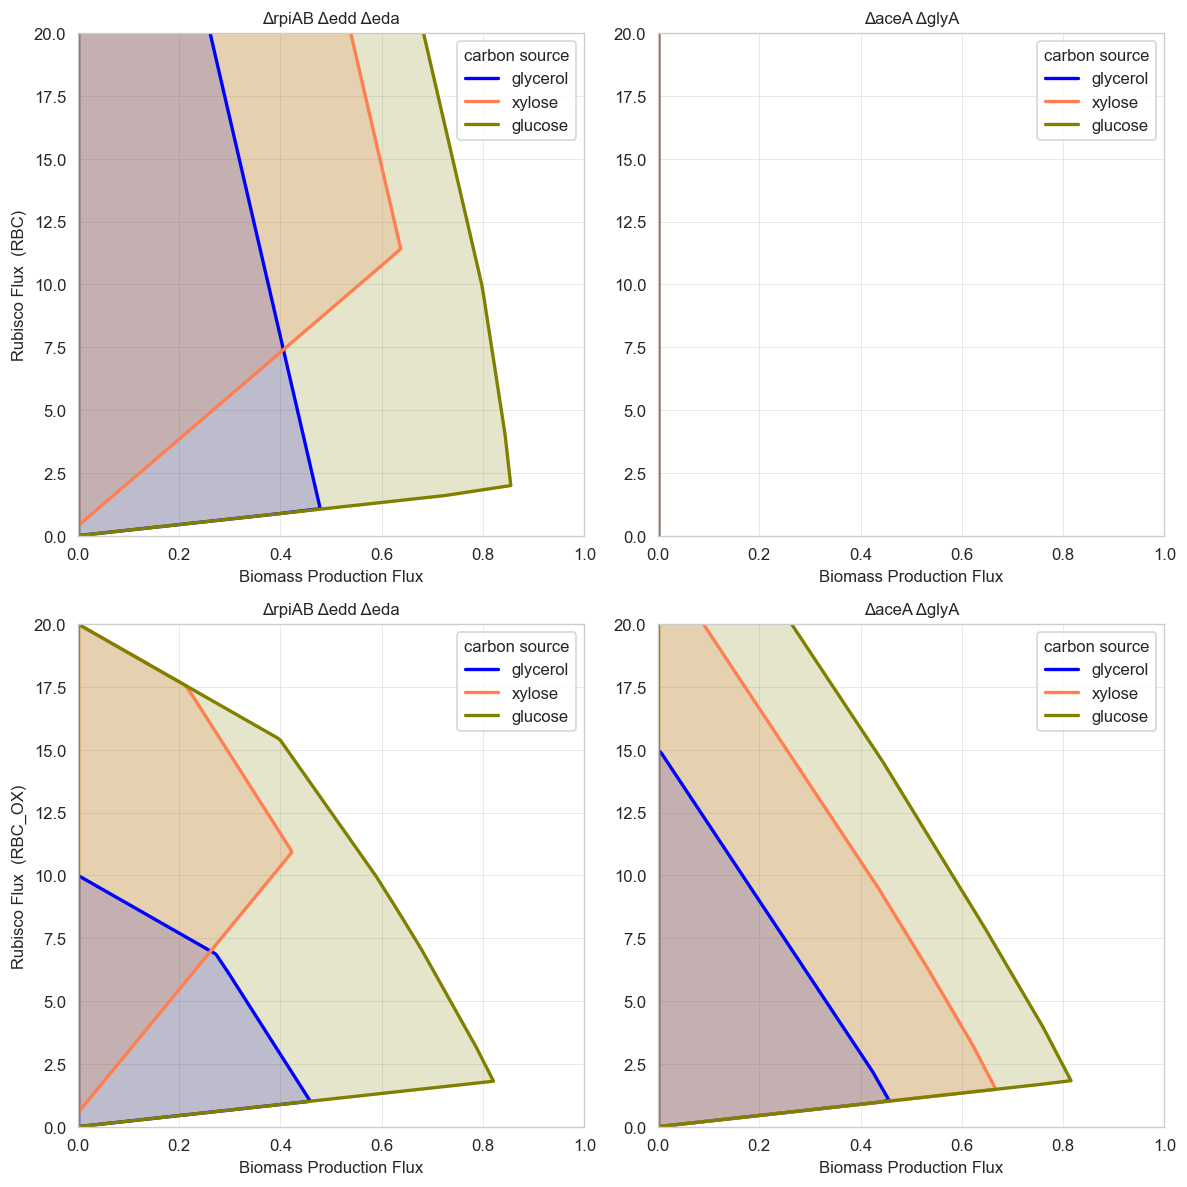

In [4]:
# Colors for plotting
colors = sns.color_palette()

# gapA KO was previously published by Mueller-Cajar '07 and others.
# Plot shows that this strain has slope 0 on sample carbon sources.
# Carbon sources are the real substrate exchanges in iCH360 (which has full
# glycerol/xylose/glucose catabolism), rather than the pathway-intermediate
# proxies (dhap, xu5p__D) used with the old core model.

csources_list = [
    (['glyc'], 'glycerol', "blue"),
    (['xyl__D'], 'xylose', "coral"),
    (["glc__D"], 'glucose', "olive")
]

# The Entner-Doudoroff pathway (EDD/EDA) was added to iCH360, so the original
# ΔrpiAB Δedd mutant can be reproduced exactly.
mutant_list = [
    #(["GAPD", "EDD", "EDA"], "ΔgapA Δedd Δeda"),
    (["RPI", "EDD", "EDA"], "ΔrpiAB Δedd Δeda"),
    (["ICL", "GHMT2r"], "ΔaceA ΔglyA"),
]

fig, axs = plt.subplots(2, len(mutant_list), figsize=(10, 10), dpi=120)

for i, (target_reaction, extra_ko) in enumerate([("RBC", "RBC_OX"), ("RBC_OX", "RBC")]):
    for j, (knockouts, mutant_name) in enumerate(mutant_list):
        ax = axs[i, j]
        for csources, csource_name, c in csources_list:
            plot_envelope(
                wt_model,
                knockouts=knockouts + [extra_ko],
                carbon_sources=csources,
                target_reaction=target_reaction,
                ax=ax,
                label=csource_name,
                color=c)

        ax.set_title(mutant_name, fontsize=10)
        ax.set_xlabel('Biomass Production Flux')
        if j == 0:
            ax.set_ylabel('Rubisco Flux  (' + target_reaction + ')')
        ax.set_ylim(0, 20)
        ax.set_xlim(0, 1)
        ax.legend(loc="upper right", title="carbon source")

fig.tight_layout()
fig.savefig("comparison_to_rpi.svg")
display(fig)
plt.close(fig)

## O₂/CO₂ ratio sweep (carboxylation vs. oxygenation)

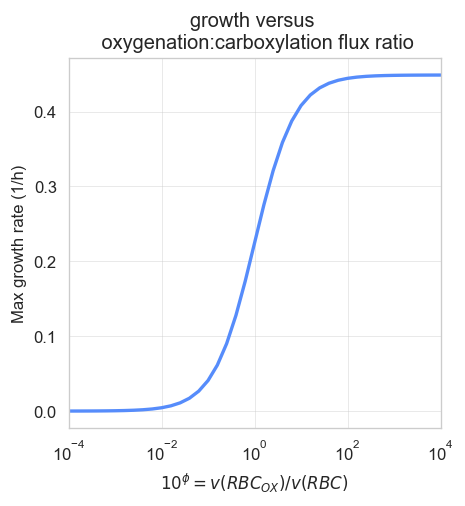

In [5]:
csources = ['glyc']
knockouts = ["ICL", "GHMT2r"]
phis = np.linspace(-4, 4, 41)

def growth_vs_ox_ratio(
        wt_model: model,
        knockouts: Iterable[str],
        carbon_sources: Iterable[str],
        log_ratios: Iterable[float]) -> pd.DataFrame:
    """Max growth rate as a function of the imposed oxygenation:carboxylation
    flux ratio, parameterised by phi = log10(v(RBC_OX) / v(RBC)).

    For each phi the imposed ratio is 10**phi. RBC_OX is excluded from the
    knockout set here (it is the reaction being swept).
    """
    knockouts = [ko for ko in knockouts if ko != "RBC_OX"]
    growth = []
    for phi in log_ratios:
        ratio = 10.0 ** phi
        ko_model = wt_model.copy()
        for ko in knockouts:
            for k in ko.split('|'):
                ko_model.reactions.get_by_id(k).knock_out()
        ko_model.reactions.EX_glc__D_e.lower_bound = 0.0
        # we use very loose bounds for uptake rates (so it will not limit growth)
        for cs in carbon_sources:
            ko_model.reactions.get_by_id("EX_" + cs + "_e").lower_bound = -100
        # impose v(RBC_OX) = 10**phi * v(RBC)
        constr = ko_model.problem.Constraint(
            ko_model.reactions.RBC_OX.flux_expression
            - ratio * ko_model.reactions.RBC.flux_expression,
            lb=0, ub=0, name="ox_carb_ratio")
        # sum of the two fluxes is v(RBC) * (1 + 10**phi).
        # in order to make Rubisco the bottleneck,
        # we now constrain the sum to be 1 umol/min/gCDW which means
        # v(RBC) <= 10/(1+10**phi)
        ko_model.reactions.RBC.upper_bound = 1 / (1 + ratio)
        ko_model.add_cons_vars(constr)
        growth.append(ko_model.slim_optimize())
    return pd.DataFrame({"phi": list(log_ratios), "growth": growth})


fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=120)

df = growth_vs_ox_ratio(wt_model, knockouts, csources, phis)
ax.plot(10**df.phi, df.growth, lw=2, label=csource_name)
ax.set_title("growth versus \n oxygenation:carboxylation flux ratio")
ax.set_xlabel(r'$10^{\phi} = v(RBC_{OX}) / v(RBC)$')
ax.set_ylabel('Max growth rate (1/h)')
ax.set_xlim(10**phis.min(), 10**phis.max())
ax.set_xscale("log")

fig.savefig("yield_vs_phi.svg")
display(fig)
plt.close(fig)

## Phenotypic phase planes of GLY-AUX2 for different values of φ

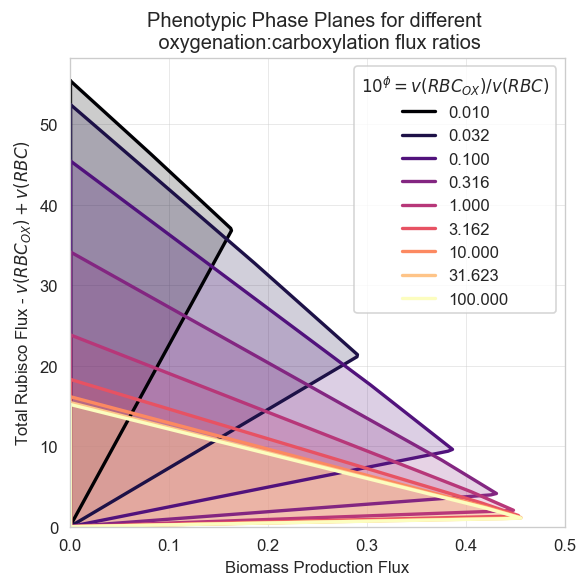

In [6]:
# Colors for plotting
colors = sns.color_palette()

csources = ['glyc']
knockouts = ["ICL", "GHMT2r"]
phis = np.linspace(-2, 2, 9)

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=120)

colors = plt.colormaps.get_cmap("magma")(np.linspace(0, 1, len(phis)))

for phi, c in zip(phis, colors):
    ratio = 10.0 ** phi
    rbc_model = wt_model.copy()
    constr = rbc_model.problem.Constraint(
        rbc_model.reactions.RBC_OX.flux_expression
        - ratio * rbc_model.reactions.RBC.flux_expression,
        lb=0, ub=0, name="ox_carb_ratio")
    rbc_model.add_cons_vars(constr)

    # The envelope is computed by sweeping RBC, but RBC_OX is pinned to
    # ratio*RBC, so the total Rubisco flux is RBC*(1 + ratio). Scale the
    # y-axis by (1 + ratio) to plot that total instead of carboxylation alone.
    plot_envelope(
        rbc_model,
        knockouts=knockouts,
        carbon_sources=csources,
        target_reaction="RBC",
        ax=ax,
        label=f"{ratio:.3f}",
        color=c,
        y_scale=1 + ratio)

ax.set_title("Phenotypic Phase Planes for different \n oxygenation:carboxylation flux ratios")
ax.set_xlabel('Biomass Production Flux')
ax.set_ylabel('Total Rubisco Flux - $v(RBC_{OX}) + v(RBC)$')
ax.set_ylim(0, None)
ax.set_xlim(0, 0.5)
ax.legend(loc="upper right", title=r"$10^{\phi} = v(RBC_{OX}) / v(RBC)$")

fig.tight_layout()
fig.savefig("PPP_for_different_phis.svg")
display(fig)
plt.close(fig)